In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().mean() * 100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [6]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [8]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [9]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [12]:
# Impute missing values in 'Age_imputed' for the training set
# It selects rows where 'Age_imputed' is null using .loc
# Then, it samples random values from the non-null 'Age' values in the training set
# The number of samples is equal to the number of null values in 'Age_imputed'
# Finally, it assigns these sampled values to the null 'Age_imputed' entries in the training set
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = X_train['Age'].dropna().sample(X_train['Age_imputed'].isnull().sum()).values

# Impute missing values in 'Age_imputed' for the test set
# It selects rows where 'Age_imputed' is null using .loc
# Then, it samples random values from the non-null 'Age' values in the training set
# The number of samples is equal to the number of null values in 'Age_imputed' in the test set
# Finally, it assigns these sampled values to the null 'Age_imputed' entries in the test set
# Note: We sample from the training set's non-null 'Age' values to avoid data leakage from the test set
X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = X_train['Age'].dropna().sample(X_test['Age_imputed'].isnull().sum()).values

# X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
# X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [13]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values # This are that random values which will getreplaced

array([ 3.  , 26.  , 18.  , 22.  , 18.  , 28.  , 32.  , 40.  , 19.  ,
       31.  , 24.  , 21.  , 24.  , 16.  , 37.  , 45.  , 30.5 , 24.  ,
       29.  , 51.  , 25.  ,  4.  , 25.  , 32.  , 28.  , 30.  , 25.  ,
       37.  , 36.  , 42.  , 21.  ,  9.  , 24.  , 40.5 , 16.  , 22.  ,
       40.  , 45.  , 14.  , 65.  , 13.  , 49.  , 34.  ,  2.  ,  0.75,
       42.  , 18.  , 46.  , 23.  , 30.  , 34.  , 61.  ,  2.  , 54.  ,
       20.  , 57.  , 61.  , 51.  , 34.  , 60.  , 24.  ,  0.42, 16.  ,
       24.  , 22.  , 25.  ,  9.  , 27.  , 31.  , 32.  , 22.  , 34.  ,
       27.  , 40.  , 20.  , 30.  , 28.  , 45.  , 39.  , 32.  , 44.  ,
       28.  , 45.  , 45.  , 36.  , 42.  , 31.  , 24.  ,  4.  , 47.  ,
       26.  , 26.  , 56.  , 21.  , 27.  , 21.  , 27.  , 29.  , 45.  ,
        1.  , 23.5 , 41.  , 35.  , 19.  , 26.  , 35.  , 42.  , 16.  ,
       36.  , 24.  , 22.  , 58.  , 29.  , 50.  , 42.  , 38.  , 30.  ,
       62.  , 33.  ,  4.  , 17.  , 19.  , 31.  , 39.  , 22.  , 40.  ,
       40.  , 18.  ,

In [14]:
X_train['Age'].isnull().sum()

np.int64(148)

In [15]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,1.0
493,71.0,49.5042,71.0
527,NaN,221.7792,33.0


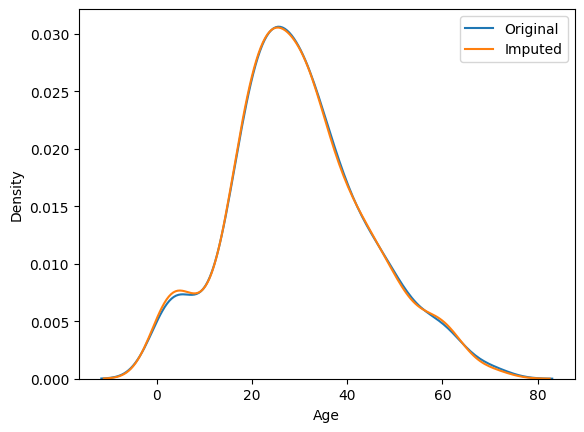

In [19]:
sns.kdeplot(X_train['Age'],label='Original')
sns.kdeplot(X_train['Age_imputed'],label = 'Imputed')

plt.legend()
plt.show()

In [20]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  204.8588468085776


In [21]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,57.065870
Age,71.512440,204.349513,204.349513
Age_imputed,57.065870,204.349513,204.858847


<Axes: >

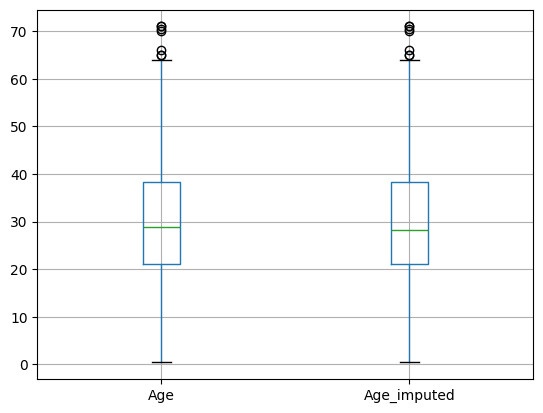

In [22]:
X_train[['Age', 'Age_imputed']].boxplot()

In [24]:
sampled_value = X_train['Age'].dropna().sample(1, random_state=2)